In [1]:
from Configurations.imports import *
from Configurations.file_path import data_parent_path

In [2]:
file = data_parent_path / "cleaned_dataset.csv"
df = pd.read_csv(file)
df.head()

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not_fire,1
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not_fire,1
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not_fire,1
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not_fire,1
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not_fire,1


#### Problem Statement: Fire Weather Index (FWI) Prediction

#### Objective
To build a regression model that predicts the **Fire Weather Index (FWI)** using meteorological and environmental features.

---

#### Problem Description
Forest fires are influenced by multiple environmental factors such as temperature, humidity, wind speed, and rainfall. The **FWI (Fire Weather Index)** is a key indicator used to measure fire intensity and risk.

The goal is to develop a machine learning model that can accurately predict the **FWI value** based on given input features, enabling better fire risk assessment and preventive planning.

---

#### Input Features (Independent Variables)
- Temperature  
- RH (Relative Humidity)  
- WS (Wind Speed)  
- Rain  
- FFMC  
- DMC  
- DC  
- ISI  
- BUI  
- Region  

---

#### Target Variable (Dependent Variable)
- FWI (Fire Weather Index)

---

#### Task Type
- Supervised Learning  
- Regression Problem  

---

#### Expected Outcome
- Predict continuous FWI values  
- Understand how environmental factors influence fire intensity  
- Assist in early fire risk detection and decision-making  

---

In [3]:
# removing unnecessary columns from the df
df = df.drop(["day","month","year"], axis=1)
df.head()

,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,classes,region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not_fire,1
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not_fire,1
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not_fire,1
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not_fire,1
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not_fire,1


In [4]:
# checking the classes
df["classes"].value_counts()

#encode the classes
df["classes"] = np.where(df["classes"].str.contains("not_fire"),0,1)

In [5]:
# getting the dependent and independent features
x = df.drop("fwi", axis=1)
y = df["fwi"]

x.head()
y.head()

0    0.5
1    0.4
2    0.1
3    0.0
4    0.5
Name: fwi, dtype: float64

In [6]:
# splitting the dataset into test and train split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.25, random_state=42)

In [7]:
# checking the shape
x_train.shape
x_test.shape

y_train.shape
y_test.shape

(61,)

#### Applying Feature Selection

1) Removing Unwanted and duplicate columns (done)
2) removing the highly correlated columns to avoid overfitting
3) removing the weakly correlated columns that has negligible impact

In [27]:
# removing the highly colinear columns and weakly colinear columns

up_threshold = 0.95
low_threshold = 0.10

targets = df.corr()["fwi"].drop("fwi")

selected_features = targets[
    (targets.abs() > low_threshold) & 
    (targets.abs() < up_threshold)
]

targets

temperature    0.566670
rh            -0.580957
ws             0.032368
rain          -0.324422
ffmc           0.691132
dmc            0.875864
dc             0.739521
isi            0.922895
bui            0.857973
classes        0.719216
region        -0.197102
Name: fwi, dtype: float64

In [9]:
x_train = x_train[selected_features.index]
x_test = x_test[selected_features.index]

In [26]:
x_train.head()

,temperature,rh,rain,ffmc,dmc,dc,isi,bui,classes,region
97,29,74,0.1,75.8,3.6,32.2,2.1,5.6,0,1
141,31,72,0.2,60.2,3.8,8.0,0.8,3.7,0,0
192,40,31,0.0,94.2,22.5,46.3,16.6,22.4,1,0
68,32,60,0.3,77.1,11.3,47.0,2.2,14.1,0,1
119,32,47,0.7,77.5,7.1,8.8,1.8,6.8,0,1


In [10]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

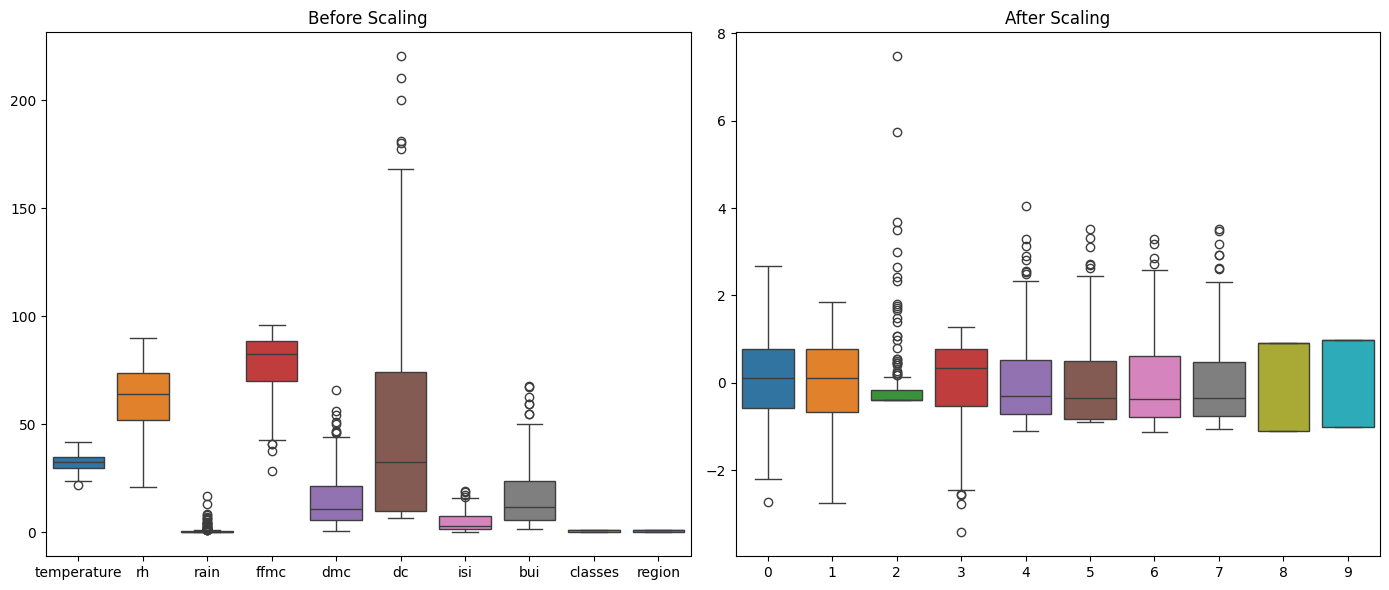

In [11]:
# lets see how it looks after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before Scaling
sns.boxplot(data=x_train, ax=axes[0])
axes[0].set_title("Before Scaling")

# After Scaling
sns.boxplot(data=x_train_scaled, ax=axes[1])
axes[1].set_title("After Scaling")

plt.tight_layout()
plt.show()

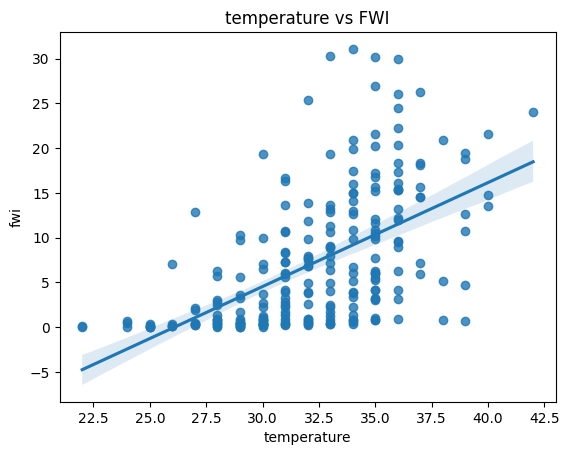

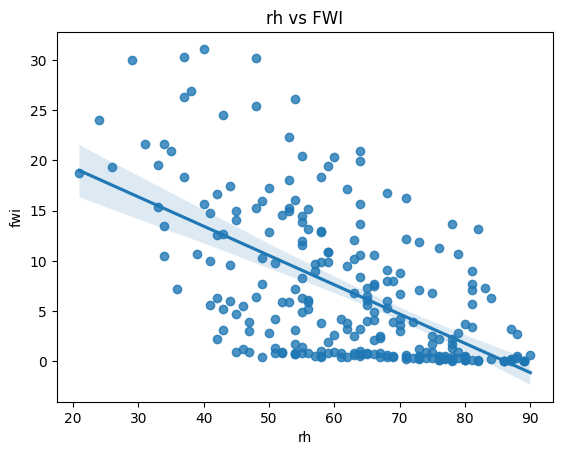

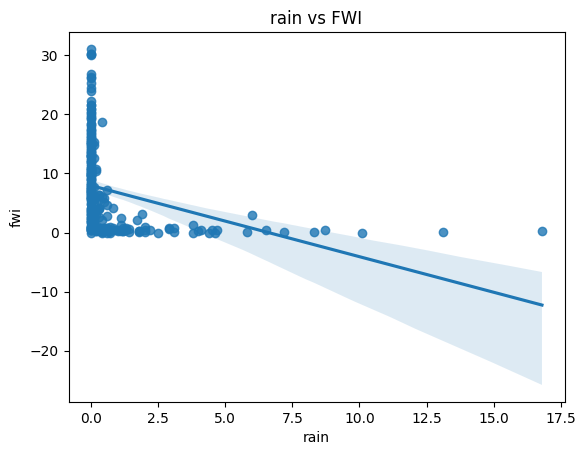

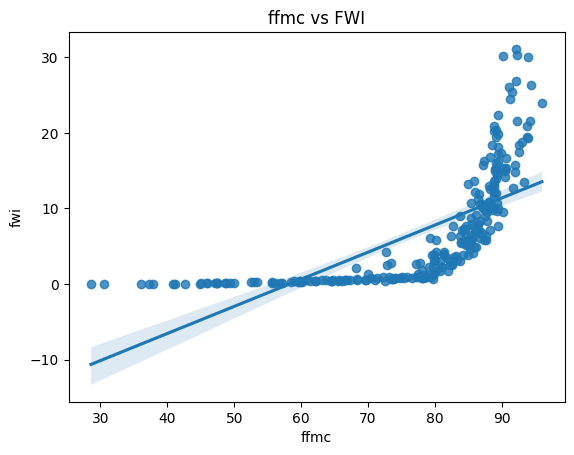

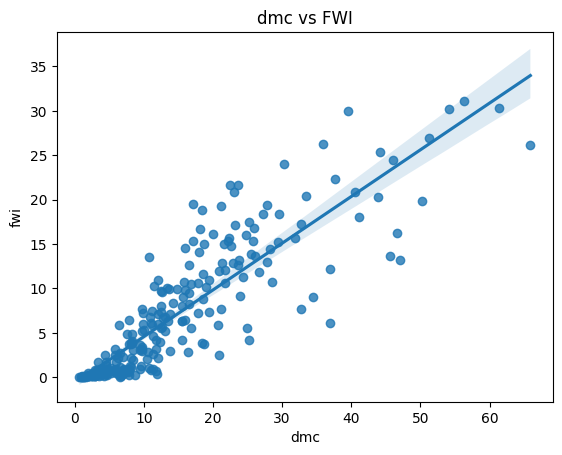

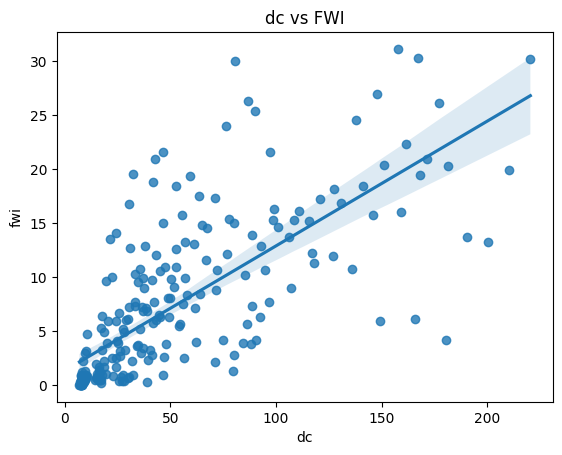

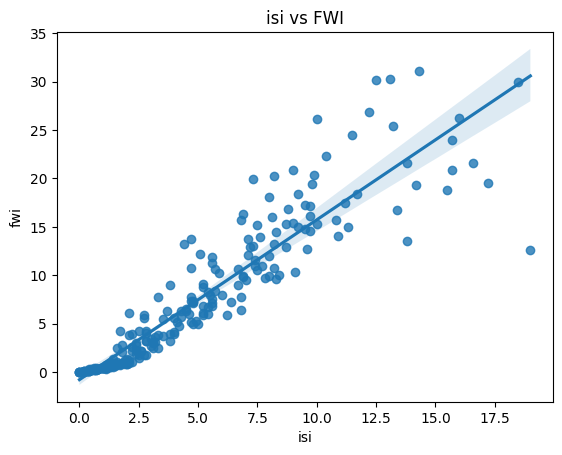

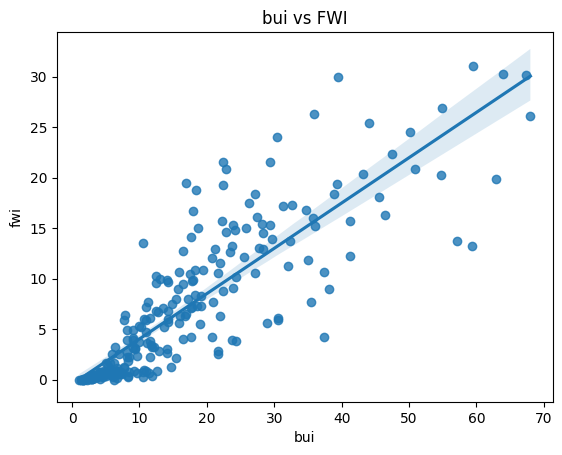

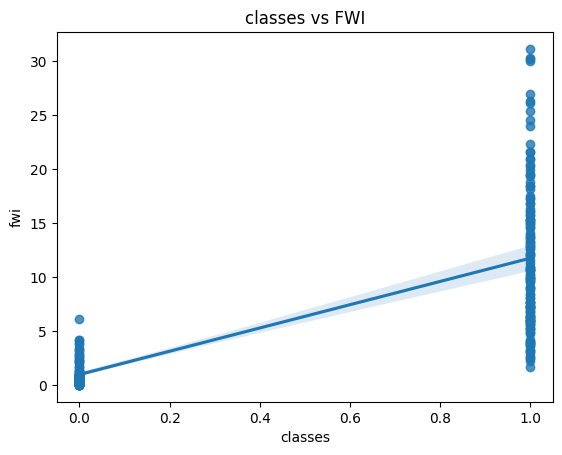

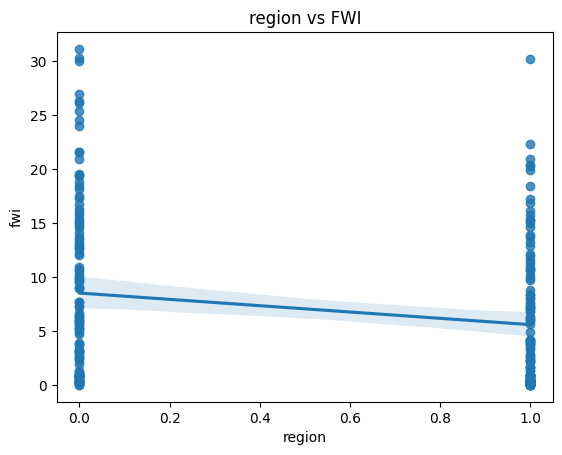

In [12]:
# check the relationship between the features
for col in selected_features.index:
    plt.figure()
    sns.regplot(x=df[col], y=df["fwi"])
    plt.title(f"{col} vs FWI")
    plt.show()

What you observed

👉 Most features → linear relationship with FWI \
👉 FFMC → curved (non-linear)

In [13]:
# Multiple Linear Regression
from sklearn.linear_model import LinearRegression
regressor = LinearRegression(n_jobs=-1)

regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

In [14]:
# evaluation
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print("Accuracy: " , round(score * 100, 2))

# definitely it has overfitting

Accuracy:  99.0


In [15]:
print("Train R2:", regressor.score(x_train_scaled, y_train))
print("Test R2:", regressor.score(x_test_scaled, y_test))

Train R2: 0.9722959530180497
Test R2: 0.9899766542095637


#### Implementation of regularization technique

In [16]:
# Ridge Regression

from sklearn.linear_model import Ridge
regressor = Ridge()

regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

print("Train R2:", regressor.score(x_train_scaled, y_train))
print("Test R2:", regressor.score(x_test_scaled, y_test))

Train R2: 0.9720997160185552
Test R2: 0.9876882150655838


In [17]:
# Lasso Regression
from sklearn.linear_model import Lasso
regressor = Lasso()

regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

print("Train R2:", regressor.score(x_train_scaled, y_train))
print("Test R2:", regressor.score(x_test_scaled, y_test))

Train R2: 0.9471535313241867
Test R2: 0.954811726653942


In [18]:
# Elastic Net Regression
from sklearn.linear_model import ElasticNet
regressor = ElasticNet()

regressor.fit(x_train_scaled, y_train)
y_pred = regressor.predict(x_test_scaled)

print("Train R2:", regressor.score(x_train_scaled, y_train))
print("Test R2:", regressor.score(x_test_scaled, y_test))

Train R2: 0.9099415746790607
Test R2: 0.9006714541990984


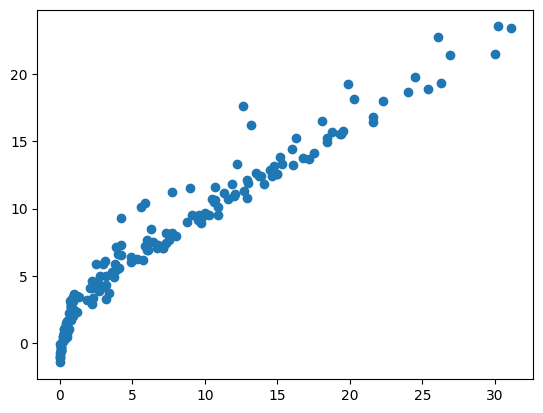

In [19]:
plt.scatter(y_train, regressor.predict(x_train_scaled))

#### Cross Validation

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
regressor = LinearRegression(n_jobs=-1)

# Perform 5-fold cross-validation (cv=5)
scores = cross_val_score(regressor,x_train_scaled,y_train,cv=5)
print(scores)

[0.98747773 0.98208343 0.85516253 0.9794635  0.97227505]


#### Cross Validation with the Regularisation

In [21]:
from sklearn.linear_model import LassoCV

regressor = LassoCV(cv=5)

regressor.fit(x_train_scaled, y_train)

y_pred = regressor.predict(x_test_scaled)

print("Train R2:", regressor.score(x_train_scaled, y_train))
print("Test R2:", regressor.score(x_test_scaled, y_test))

# from sklearn.linear_model import RidgeCV
# from sklearn.linear_model import ElasticNetCV

Train R2: 0.9713247480949203
Test R2: 0.9873481548149597


### 1. RidgeCV

#### Important PARAMETERS

```python
RidgeCV(
    alphas=[0.1, 1.0, 10.0],   # list of alpha values
    cv=5,                      # number of folds
    scoring=None               # optional metric
)
```

#### Key ones:

* `alphas`  → regularization strengths
* `cv`  → cross-validation folds

---

####  Important ATTRIBUTES (after fit)

```python
model.alpha_        # best alpha 
model.coef_         # coefficients
model.intercept_    # intercept
```

---

#### Behavior

* Shrinks coefficients
* NEVER makes them zero

---

###  2. LassoCV

####  Important PARAMETERS

```python
LassoCV(
    alphas=None,        # auto-generated if None
    cv=5,               # folds
    max_iter=1000,      # iterations
    n_jobs=-1           # parallel
)
```

#### Key ones:

* `alphas` 
* `cv` 
* `max_iter` (important if convergence issues)

---

####  Important ATTRIBUTES

```python
model.alpha_        # best alpha 
model.coef_         # coefficients (some = 0) 
model.intercept_
model.alphas_       # all tested alphas
model.mse_path_     # errors per alpha
```

---

#### Behavior

* Shrinks + sets some coefficients to **zero**
* Does **feature selection**

---

###  3. ElasticNetCV

####  Important PARAMETERS

```python
ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.9],   # mix between L1 & L2 
    alphas=None,
    cv=5,
    max_iter=1000
)
```

#### Key ones:

* `l1_ratio`  → balance between Ridge & Lasso
* `alphas` 
* `cv` 

---

#### Important ATTRIBUTES

```python
model.alpha_        # best alpha 
model.l1_ratio_     # best mix 
model.coef_         # coefficients
model.intercept_
model.alphas_
model.mse_path_
```

---



In [22]:
x_train.head()

,temperature,rh,rain,ffmc,dmc,dc,isi,bui,classes,region
97,29,74,0.1,75.8,3.6,32.2,2.1,5.6,0,1
141,31,72,0.2,60.2,3.8,8.0,0.8,3.7,0,0
192,40,31,0.0,94.2,22.5,46.3,16.6,22.4,1,0
68,32,60,0.3,77.1,11.3,47.0,2.2,14.1,0,1
119,32,47,0.7,77.5,7.1,8.8,1.8,6.8,0,1


array([[-0.84284248,  0.78307967, -0.33727373, ..., -0.77269802,
        -1.10431526,  0.98907071],
       [-0.30175842,  0.64950844, -0.29048728, ..., -0.90344718,
        -1.10431526, -1.01105006],
       [ 2.13311985, -2.08870172, -0.38406017, ...,  0.38339978,
         0.90553851, -1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  2.984564  , ..., -1.03419633,
        -1.10431526,  0.98907071],
       [ 0.50986767, -0.21870454, -0.38406017, ...,  0.18383528,
         0.90553851, -1.01105006],
       [-0.57230045,  0.98343651,  0.45809587, ..., -0.99290713,
        -1.10431526,  0.98907071]], shape=(182, 10))